# Model Inference

In [19]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler

import mlflow
import mlflow.sklearn
import dagshub

In [20]:
dagshub.init(repo_owner='rkvit23', repo_name='ML-HW1', mlflow=True)
mlflow.set_tracking_uri("https://dagshub.com/rkvit23/ML-HW1.mlflow")

Initialized MLflow to track repo "rkvit23/ML-HW1"

Repository rkvit23/ML-HW1 initialized!

## 1. Load Model from Registry

In [22]:
model_name = "HousePrices_Final"
model_uri = f"models:/{model_name}/latest"

print(f"Loading model from: {model_uri}")
model = mlflow.sklearn.load_model(model_uri)
print(f"Model loaded: {type(model).__name__}")
print(model)

expected_features = model.feature_names_in_
print(f"\nModel expects {len(expected_features)} features")

Loading model from: models:/HousePrices_Final/latest
Model loaded: Ridge
Ridge()

Model expects 45 features


## 2. Load Data

In [23]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

test_ids = test_df['Id'].copy()

outliers = train_df[(train_df['GrLivArea'] > 4000) & (train_df['SalePrice'] < 300000)]
train_df = train_df.drop(outliers.index)

y_log = np.log1p(train_df['SalePrice'])
X_train_raw = train_df.drop(['SalePrice', 'Id'], axis=1)
X_test_raw = test_df.drop('Id', axis=1)

print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")

Train: (1458, 79), Test: (1459, 79)


## 3. Apply Same Preprocessing as Training

In [24]:
NA_MEANS_NONE_CAT = [
    'Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence', 'MiscFeature', 'MasVnrType'
]
NA_MEANS_ZERO_NUM = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]

def clean(X, train_ref):
    X = X.copy()
    for col in NA_MEANS_NONE_CAT:
        if col in X.columns:
            X[col] = X[col].fillna('None')
    for col in NA_MEANS_ZERO_NUM:
        if col in X.columns:
            X[col] = X[col].fillna(0)
    if 'LotFrontage' in X.columns and X['LotFrontage'].isnull().any():
        medians = train_ref.groupby('Neighborhood')['LotFrontage'].median()
        global_med = train_ref['LotFrontage'].median()
        X['LotFrontage'] = X.apply(
            lambda r: medians.get(r['Neighborhood'], global_med)
            if pd.isnull(r['LotFrontage']) else r['LotFrontage'], axis=1)
    if 'Electrical' in X.columns:
        X['Electrical'] = X['Electrical'].fillna(train_ref['Electrical'].mode()[0])
    cat_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    for c in cat_cols:
        if c not in NA_MEANS_NONE_CAT and X[c].isnull().any():
            X[c] = X[c].fillna(train_ref[c].mode()[0] if c in train_ref.columns else 'None')
    for c in X.select_dtypes(include='number').columns:
        if X[c].isnull().any():
            X[c] = X[c].fillna(train_ref[c].median() if c in train_ref.columns else 0)
    return X

X_train_clean = clean(X_train_raw, X_train_raw)
X_test_clean = clean(X_test_raw, X_train_raw)
print(f"Missing after cleaning — Train: {X_train_clean.isnull().sum().sum()}, Test: {X_test_clean.isnull().sum().sum()}")

Missing after cleaning — Train: 0, Test: 0


In [25]:
ORDINAL_MAP = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
ORDINAL_COLS = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
                'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

def feature_engineer(X):
    X = X.copy()
    X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
    X['TotalBath'] = X['FullBath'] + 0.5*X['HalfBath'] + X['BsmtFullBath'] + 0.5*X['BsmtHalfBath']
    X['TotalPorchSF'] = X['OpenPorchSF'] + X['EnclosedPorch'] + X['3SsnPorch'] + X['ScreenPorch']
    X['HouseAge'] = X['YrSold'] - X['YearBuilt']
    X['RemodAge'] = X['YrSold'] - X['YearRemodAdd']
    X['IsRemodeled'] = (X['YearBuilt'] != X['YearRemodAdd']).astype(int)
    X['HasGarage'] = (X['GarageArea'] > 0).astype(int)
    X['HasBsmt'] = (X['TotalBsmtSF'] > 0).astype(int)
    X['HasPool'] = (X['PoolArea'] > 0).astype(int)
    X['HasFireplace'] = (X['Fireplaces'] > 0).astype(int)
    X['Has2ndFloor'] = (X['2ndFlrSF'] > 0).astype(int)
    for col in ORDINAL_COLS:
        if col in X.columns:
            X[col] = X[col].map(ORDINAL_MAP).fillna(0).astype(int)
    if 'BsmtExposure' in X.columns:
        X['BsmtExposure'] = X['BsmtExposure'].map({'None':0,'No':1,'Mn':2,'Av':3,'Gd':4}).fillna(0).astype(int)
    if 'BsmtFinType1' in X.columns:
        X['BsmtFinType1'] = X['BsmtFinType1'].map({'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6}).fillna(0).astype(int)
    if 'BsmtFinType2' in X.columns:
        X['BsmtFinType2'] = X['BsmtFinType2'].map({'None':0,'Unf':1,'LwQ':2,'Rec':3,'BLQ':4,'ALQ':5,'GLQ':6}).fillna(0).astype(int)
    if 'Functional' in X.columns:
        X['Functional'] = X['Functional'].map({'Sal':1,'Sev':2,'Maj2':3,'Maj1':4,'Mod':5,'Min2':6,'Min1':7,'Typ':8}).fillna(0).astype(int)
    if 'GarageFinish' in X.columns:
        X['GarageFinish'] = X['GarageFinish'].map({'None':0,'Unf':1,'RFn':2,'Fin':3}).fillna(0).astype(int)
    if 'Fence' in X.columns:
        X['Fence'] = X['Fence'].map({'None':0,'MnWw':1,'GdWo':2,'MnPrv':3,'GdPrv':4}).fillna(0).astype(int)
    if 'CentralAir' in X.columns:
        X['CentralAir'] = (X['CentralAir'] == 'Y').astype(int)
    if 'PavedDrive' in X.columns:
        X['PavedDrive'] = X['PavedDrive'].map({'N':0,'P':1,'Y':2}).fillna(0).astype(int)
    if 'Street' in X.columns:
        X['Street'] = (X['Street'] == 'Pave').astype(int)
    return X

X_train_feat = feature_engineer(X_train_clean)
X_test_feat = feature_engineer(X_test_clean)
print(f"After feature engineering: Train {X_train_feat.shape}, Test {X_test_feat.shape}")

After feature engineering: Train (1458, 90), Test (1459, 90)


In [26]:
NOMINAL_COLS = [
    'MSZoning', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
    'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd',
    'MasVnrType', 'Foundation', 'Heating', 'Electrical', 'GarageType',
    'MiscFeature', 'SaleType', 'SaleCondition'
]
NOMINAL_COLS = [c for c in NOMINAL_COLS if c in X_train_feat.columns]

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
ohe.fit(X_train_feat[NOMINAL_COLS])

other_cols = [c for c in X_train_feat.columns if c not in NOMINAL_COLS]

def encode(X):
    encoded = ohe.transform(X[NOMINAL_COLS])
    encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(NOMINAL_COLS), index=X.index)
    return pd.concat([X[other_cols].reset_index(drop=True),
                      encoded_df.reset_index(drop=True)], axis=1)

X_train_encoded = encode(X_train_feat)
X_test_encoded = encode(X_test_feat)
print(f"After encoding: Train {X_train_encoded.shape}, Test {X_test_encoded.shape}")

After encoding: Train (1458, 215), Test (1459, 215)


In [27]:
num_cols = X_train_encoded.select_dtypes(include='number').columns
skewed = X_train_encoded[num_cols].apply(lambda x: x.skew())
skewed_features = skewed[skewed.abs() > 0.75].index.tolist()

for col in skewed_features:
    if (X_train_encoded[col] >= 0).all():
        X_train_encoded[col] = np.log1p(X_train_encoded[col])
        X_test_encoded[col] = np.log1p(X_test_encoded[col])

corr_matrix = X_train_encoded.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

X_train_processed = X_train_encoded.drop(columns=corr_drop, errors='ignore')
X_test_processed = X_test_encoded.drop(columns=corr_drop, errors='ignore')
print(f"After skewness fix + corr filter: Train {X_train_processed.shape}, Test {X_test_processed.shape}")

After skewness fix + corr filter: Train (1458, 186), Test (1459, 186)


In [28]:
missing_cols = [c for c in expected_features if c not in X_test_processed.columns]
extra_cols = [c for c in X_test_processed.columns if c not in expected_features]

if missing_cols:
    print(f"Adding {len(missing_cols)} missing columns (filled with 0): {missing_cols}")
    for c in missing_cols:
        X_test_processed[c] = 0

X_test_final = X_test_processed[expected_features]

needs_scaling = type(model).__name__ in ('Ridge', 'Lasso', 'ElasticNet', 'LinearRegression')
if needs_scaling:
    scaler = StandardScaler()
    scaler.fit(X_train_processed[expected_features])
    X_test_final = pd.DataFrame(
        scaler.transform(X_test_final),
        columns=expected_features, index=X_test_final.index
    )
    print("Applied StandardScaler (linear model)")

print(f"\nFinal test shape: {X_test_final.shape}")
print(f"Matches model expectation: {list(X_test_final.columns) == list(expected_features)}")

Applied StandardScaler (linear model)

Final test shape: (1459, 45)
Matches model expectation: True


## 4. Generate Predictions

In [29]:
preds_log = model.predict(X_test_final)

preds = np.expm1(preds_log)
preds = np.maximum(preds, 0)

print(f"Predictions shape: {preds.shape}")
print(f"Price range: ${preds.min():,.0f} - ${preds.max():,.0f}")
print(f"Mean price:  ${preds.mean():,.0f}")
print(f"Median price: ${np.median(preds):,.0f}")

Predictions shape: (1459,)
Price range: $48,679 - $1,024,743
Mean price:  $178,826
Median price: $160,156


## 5. Create Submission File

In [30]:
submission = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': preds
})

submission.to_csv('submission2.csv', index=False)
print(f"Submission saved to submission.csv")
print(f"Shape: {submission.shape}")
submission.head(10)

Submission saved to submission.csv
Shape: (1459, 2)


,Id,SalePrice
0,1461,108955.663511
1,1462,162150.461232
2,1463,179895.035072
3,1464,199902.535680
4,1465,210624.427140
5,1466,167974.485645
6,1467,175574.093791
7,1468,160704.246256
8,1469,200290.356148
9,1470,115529.255511


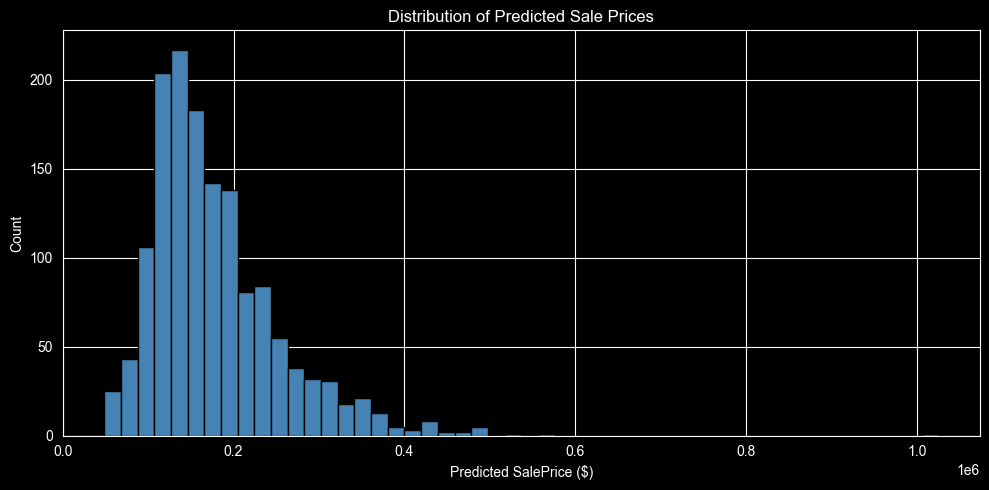

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(preds, bins=50, edgecolor='black', color='steelblue')
ax.set_xlabel('Predicted SalePrice ($)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Predicted Sale Prices')
plt.tight_layout()
plt.show()